In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import random
import math
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Preprocesamiento

In [ ]:
# Ruta a la carpeta del dataset descomprimido
dataset_path = "malimg_paper_dataset_imgs"

# Obtener todas las familias (subcarpetas)
families = sorted(os.listdir(dataset_path))

# Contar imágenes por familia
family_count = {}
for family in families:
    carpeta = os.path.join(dataset_path, family)
    if os.path.isdir(carpeta):
        family_count[family] = len(os.listdir(carpeta))
        
# Convertir a DataFrame para visualización
df_count = pd.DataFrame(list(family_count.items()), columns=["Familia", "Cantidad"])
df_count = df_count.sort_values("Cantidad", ascending=False)

# Mostrar tabla
print(df_count)

           Familia  Cantidad
2        Allaple.A      2949
3        Allaple.L      1591
24         Yuner.A       800
11   Instantaccess       431
22           VB.AT       408
10        Fakerean       381
12      Lolyda.AA1       213
7      C2LOP.gen!g       200
4    Alueron.gen!J       198
13      Lolyda.AA2       184
8   Dialplatform.B       177
9        Dontovo.A       162
15       Lolyda.AT       159
18        Rbot!gen       158
6          C2LOP.P       146
17   Obfuscator.AD       142
16     Malex.gen!J       136
21   Swizzor.gen!I       132
20   Swizzor.gen!E       128
14      Lolyda.AA3       123
0        Adialer.C       122
1        Agent.FYI       116
5        Autorun.K       106
23      Wintrim.BX        97
19      Skintrim.N        80


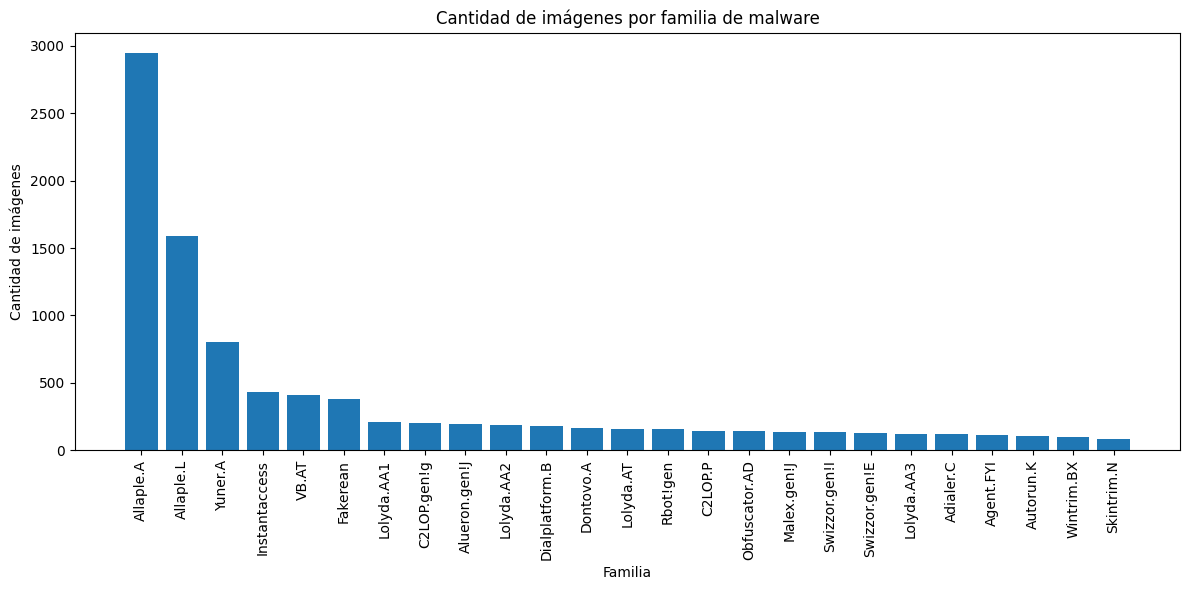

In [ ]:
# Graficar distribución
plt.figure(figsize=(12, 6))
plt.bar(df_count["Familia"], df_count["Cantidad"])
plt.xticks(rotation=90)
plt.title("Cantidad de imágenes por familia de malware")
plt.xlabel("Familia")
plt.ylabel("Cantidad de imágenes")
plt.tight_layout()
plt.show()

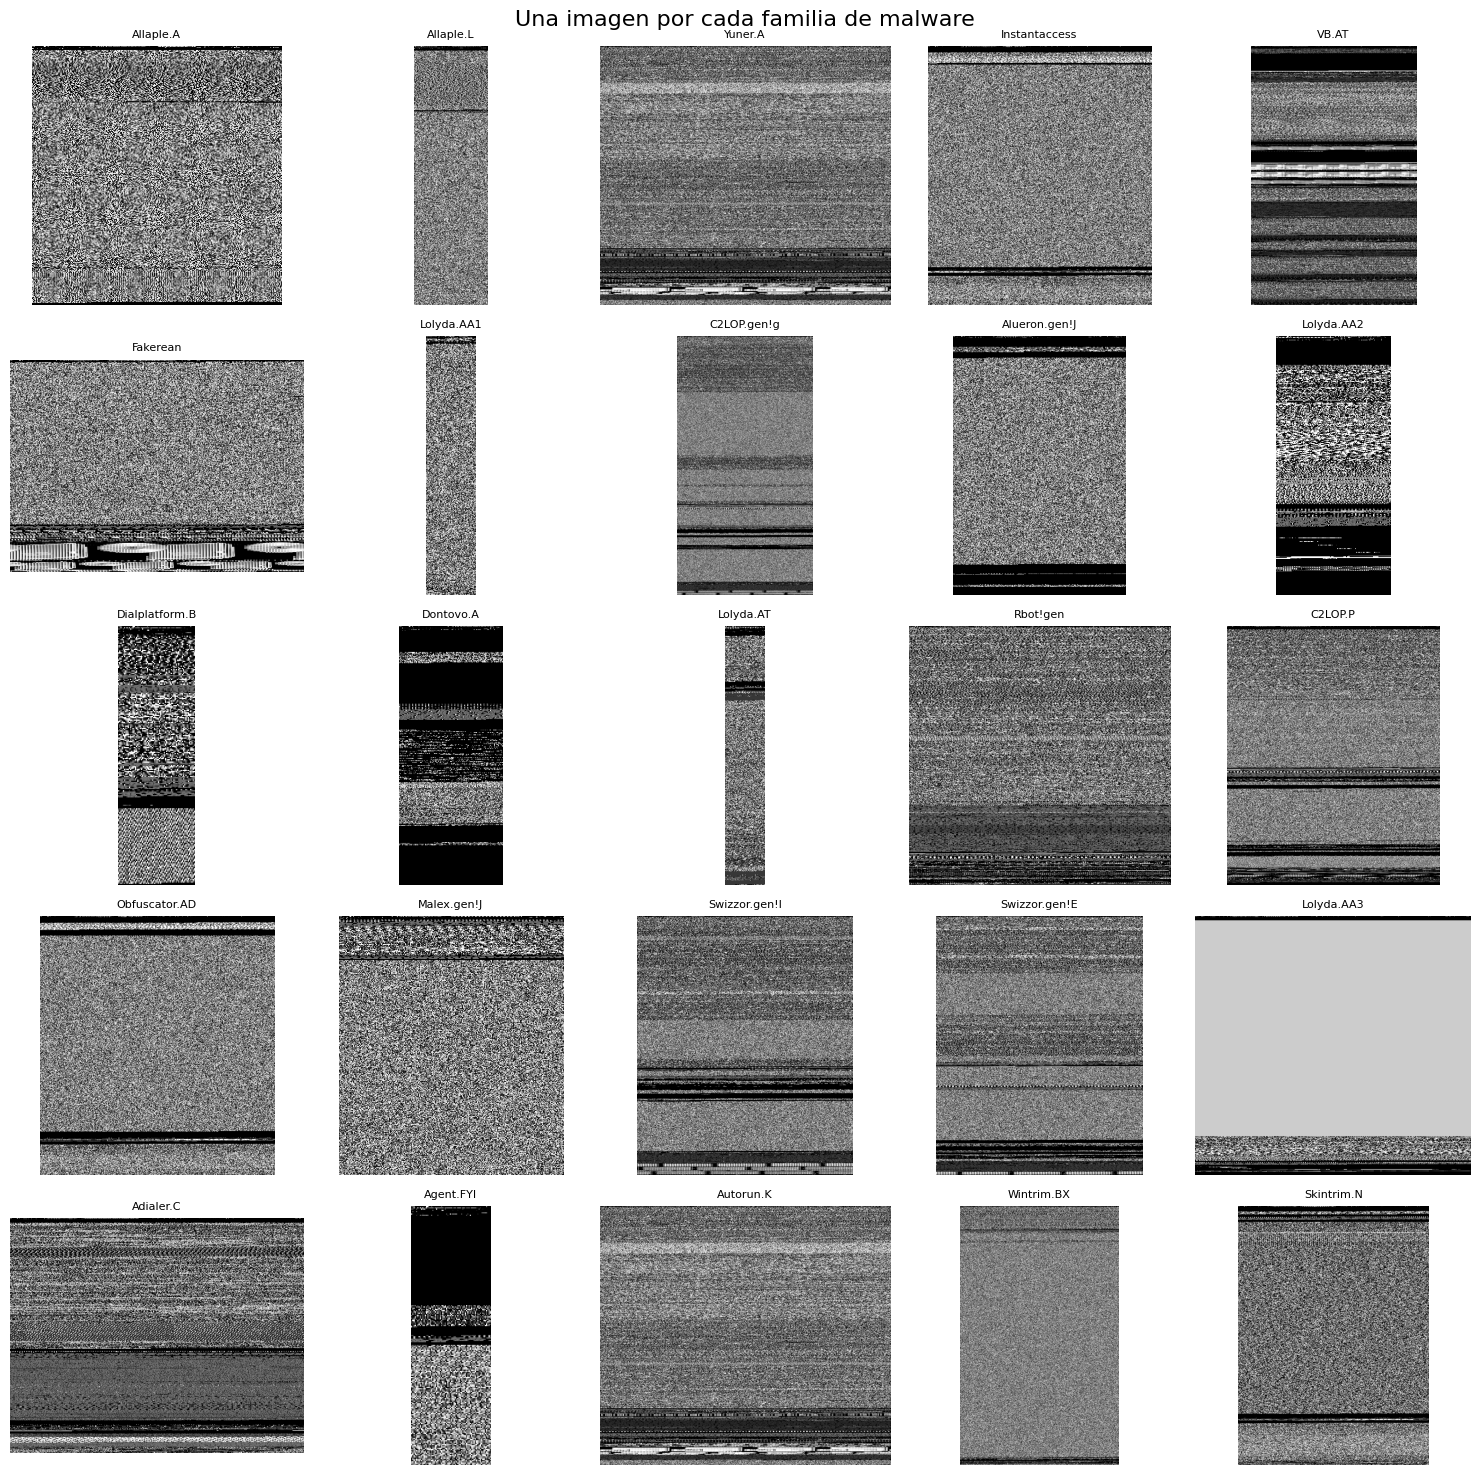

In [ ]:
# Número total de familias
total_families = len(df_count)
columns = 5
rows = math.ceil(total_families / columns)

plt.figure(figsize=(columns * 3, rows * 3))

for i, family in enumerate(df_count["Familia"]):
    folder = os.path.join(dataset_path, family)
    images = os.listdir(folder)
    selected_image = random.choice(images)
    
    image_path = os.path.join(folder, selected_image)
    img = mpimg.imread(image_path)
    
    plt.subplot(rows, columns, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(family, fontsize=8)
    plt.axis('off')

plt.suptitle("Una imagen por cada familia de malware", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Parámetros
img_height, img_width = 64, 64
batch_size = 32
seed = 42

# División del dataset: 70% entrenamiento, 30% validación
datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.3
)

# Cargar dataset de entrenamiento
train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=seed
)

# Cargar dataset de validación
val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=seed
)

Found 6549 images belonging to 25 classes.
Found 2790 images belonging to 25 classes.


## Construcción de Red Neuronal

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Número de clases
num_classes = train_generator.num_classes

# Definir el modelo
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Compilar el modelo
model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mostrar resumen
model.summary()


c:\Users\Pablo Zamora\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 686,425 (2.62 MB)

 Trainable params: 686,425 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

In [ ]:
# Entrenar el modelo
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator
)

Epoch 1/15


c:\Users\Pablo Zamora\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


205/205 ━━━━━━━━━━━━━━━━━━━━ 180s 844ms/step - accuracy: 0.3883 - loss: 2.1737 - val_accuracy: 0.7824 - val_loss: 0.7334
Epoch 2/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 25s 120ms/step - accuracy: 0.7393 - loss: 0.8104 - val_accuracy: 0.9151 - val_loss: 0.3537
Epoch 3/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 26s 125ms/step - accuracy: 0.8918 - loss: 0.3931 - val_accuracy: 0.9233 - val_loss: 0.2603
Epoch 4/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 27s 129ms/step - accuracy: 0.9010 - loss: 0.3593 - val_accuracy: 0.9254 - val_loss: 0.2946
Epoch 5/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 28s 132ms/step - accuracy: 0.9171 - loss: 0.2884 - val_accuracy: 0.9387 - val_loss: 0.2217
Epoch 6/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 26s 126ms/step - accuracy: 0.9340 - loss: 0.2138 - val_accuracy: 0.9462 - val_loss: 0.2151
Epoch 7/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 27s 127ms/step - accuracy: 0.9354 - loss: 0.1832 - val_accuracy: 0.9498 - val_loss: 0.1989
Epoch 8/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 27s 130ms/step - accuracy: 0.9395 - loss: 0.1707 - va

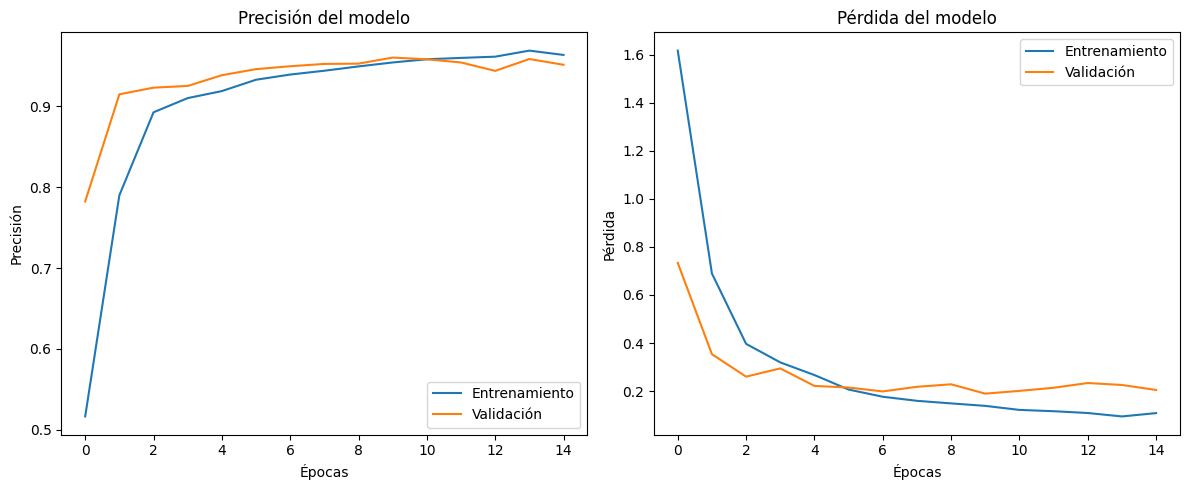

In [ ]:
# Visualizar el accuracy y loss
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del modelo')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()


## Evaluación

In [17]:
# Evaluar en el conjunto de validación
loss, accuracy = model.evaluate(val_generator)
print(f"Loss en validación: {loss:.4f}")
print(f"Accuracy en validación: {accuracy:.4f}")

88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.9798 - loss: 0.0772
Loss en validación: 0.2050
Accuracy en validación: 0.9516


In [25]:
# Obtener predicciones
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Obtener etiquetas verdaderas
y_true = val_generator.classes

# Nombres de las clases
class_names = list(val_generator.class_indices.keys())

# Reporte de clasificación
print("\nReporte de clasificación:\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step

Reporte de clasificación:

                precision    recall  f1-score   support

     Adialer.C       1.00      1.00      1.00        36
     Agent.FYI       1.00      1.00      1.00        34
     Allaple.A       0.99      1.00      1.00       884
     Allaple.L       0.99      1.00      0.99       477
 Alueron.gen!J       0.98      1.00      0.99        59
     Autorun.K       0.00      0.00      0.00        31
       C2LOP.P       0.60      0.49      0.54        43
   C2LOP.gen!g       0.82      0.83      0.83        60
Dialplatform.B       1.00      0.96      0.98        53
     Dontovo.A       1.00      1.00      1.00        48
      Fakerean       0.99      0.96      0.97       114
 Instantaccess       1.00      1.00      1.00       129
    Lolyda.AA1       0.97      1.00      0.98        63
    Lolyda.AA2       0.95      0.96      0.95        55
    Lolyda.AA3       1.00      1.00      1.00        36
     Lolyda.AT       1.00      0.94

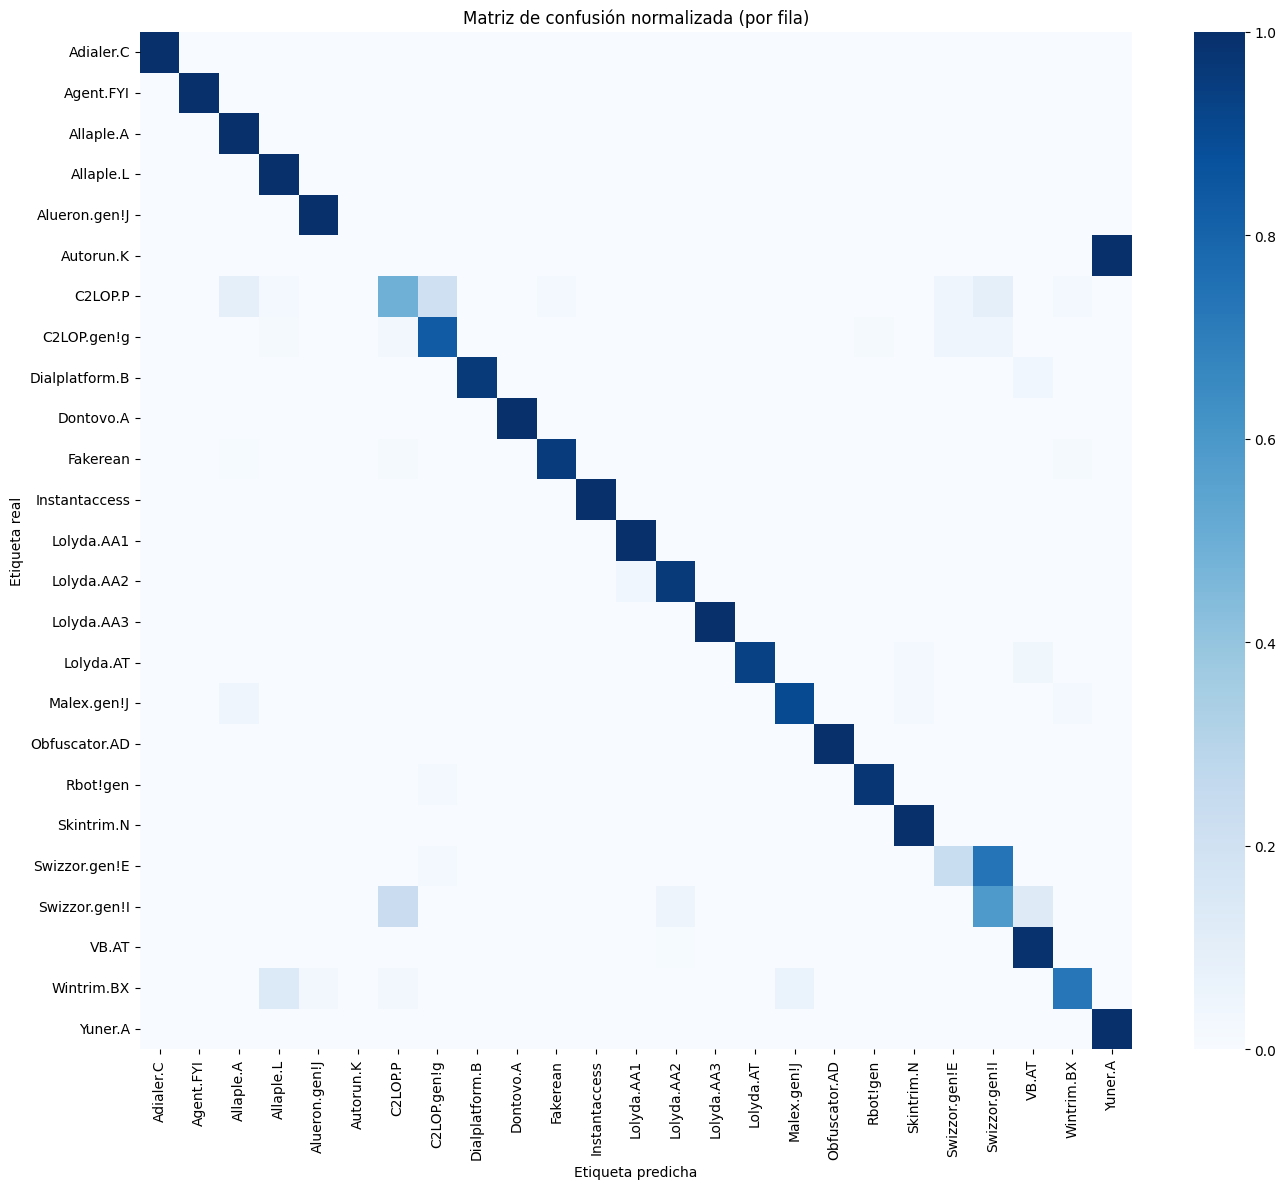

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Normalizar por fila
normalized_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot con Seaborn
plt.figure(figsize=(14, 12))
sns.heatmap(normalized_cm, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)

plt.title("Matriz de confusión normalizada (por fila)")
plt.xlabel("Etiqueta predicha")
plt.ylabel("Etiqueta real")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Discusión

En primer lugar, las curvas de entrenamiento y precisión muestran un aumento rápido de **precisión** hasta estabilizarse cerca del 0.95. Además, el hecho de que no haya una gran separación entre ambas curvas indica que no hay signos de *overfitting*; es decir, el modelo generaliza bastante bien. Por otro lado, la **pérdida** de validación baja con rapidez, luego oscila un poco, pero se mantiene baja.

El reporte de clasificación muestra un **accuracy** total de 95%, el cual es bastante aceptable para 25 clases o familias de malware a clasificar. También muestra un **weighted avg F1-score** de 94%, el cual también es altamente aceptable considerando el desbalance de muestras entre las clases. Además, en la matriz de confusión normalizada se observa que, al encontrarse en la diagonal principal, la mayoría de las se realizaron correctamente.

El reporte de clasificación también mostró que varias clases obtuvieron un F1-score de 1.00, incluyendo **Adialer.C**, **Agent.FYI**, **Dontovo.A**, **Instantaccess**, y otras, lo que indica una clasificación perfecta. Sin embargo, este reporte también mostró clases problemáticas, entre las que se encuentran, en primer lugar, **Autorun.k**, en el que se obtuvo 0 en todas las métricas, indicando que el modelo no predijo ninguna muestra de esta clase correctamente. Esto probablemente se debe a que esta es una de las clases con muy pocas muestras, contando únicamente con 31. Por otro lado, las clases **Swizzor.gen!E** y **Swizzor.gen!I** también poseen una precisión menor al 80% y un **F1-score** de 0.35 y 0.47, respectivamente.